#NBO3 DATA ANALYSIS

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/company_financials.csv")


# Define colours for consistent sector visualisation
sector_colors = {
    "Energy": "#43A047",
    "Healthcare": "#3A7BD5",
    "Technology": "#D81B60"
}


# Define company colours using the same sector undertone
company_colors = {
    # Technology
    "Microsoft": "#D81B60",
    "Nvidia": "#E75480",
    "Apple": "#F48FB1",

    # Healthcare
    "Johnson & Johnson": "#3A7BD5",
    "Pfizer": "#64B5F6",
    "Stryker": "#90CAF9",

    # Energy
    "ExxonMobil": "#43A047",
    "Chevron": "#81C784",
    "Duke Energy": "#A5D6A7"
}


# Function to display ratios as percentages
def percent_format(table):
    return table.style.format(
        lambda x: "" if pd.isna(x) else f"{x*100:.1f}%"
    )

## 1. Sector comparison

To provide an initial overview of the dataset, I compare the three sectors using the financial ratios created in NB02.

The first table presents the average values for each sector from 2018 to 2024, allowing changes over time to be observed. The second table summarises the average values across the full period, providing an overall comparison of sector performance.

The analysis focuses on four key measures:
- **R&D intensity:** research and development expenditure as a percentage of revenue.
- **Net margin:** net income as a percentage of revenue.
- **Free cash flow margin:** free cash flow as a percentage of revenue.
- **Capital expenditure intensity:** capital expenditure as a percentage of revenue.

Together, these measures provide an overview of how each sector invests in innovation, generates profits, produces cash, and finances future growth.

In [8]:
metrics = ["rd_intensity", "net_margin", "fcf_margin", "capex_intensity"]

# Sector average by year — shows how the sector picture changes 2018–2024
sector_year_summary = (
    df.groupby(["sector", "year"])[metrics]
    .mean()
)

# Sector average across the full period — one row per sector
sector_summary = (
    df.groupby("sector")[metrics]
    .mean()
)

In [9]:
sector_year_summary.style.format("{:.1%}").set_table_styles([
    {
        "selector": "th.index_name",
        "props": [("font-weight", "bold")]
    }
])

In [10]:
sector_summary.style \
    .format("{:.1%}") \
    .set_table_styles([
        {
            "selector": "th.row_heading",
            "props": [
                ("font-weight", "bold")
            ]
        }
    ]) \
    .apply_index(
        lambda x: [f"background-color: {sector_colors.get(v, '')}" for v in x],
        axis=0
    )

,rd_intensity,net_margin,fcf_margin,capex_intensity
sector,,,,
Energy,0.3%,8.2%,2.8%,18.7%
Healthcare,12.8%,19.0%,20.0%,4.2%
Technology,12.8%,30.8%,29.3%,7.7%


### Findings

- **Technology companies combine high innovation investment with the strongest profitability and free cash flow generation.** They invest around 13% of revenue in R&D while maintaining the highest net and free cash flow margins.

- **Healthcare companies also invest heavily in R&D but generate lower profitability than technology firms.** Their results indicate an innovation-driven sector with strong but more moderate financial performance.

- **Energy companies spend very little on R&D and exhibit lower, more volatile profitability and cash generation.** Instead, they record the highest capital expenditure intensity, reflecting reliance on physical assets and infrastructure rather than research-led growth.

Overall, the sector averages suggest that technology and healthcare pursue innovation-driven growth strategies, whereas energy companies depend more heavily on capital investment and operational assets.

## 2. Analyse differences in R&D investment

R&D intensity measures how much of a company's revenue is allocated to research and development.

A higher R&D intensity suggests that a sector relies more heavily on innovation and product development as part of its growth strategy.

The following chart and table compare R&D intensity across sectors and companies to identify which industries and firms invest more heavily in innovation relative to their revenue.

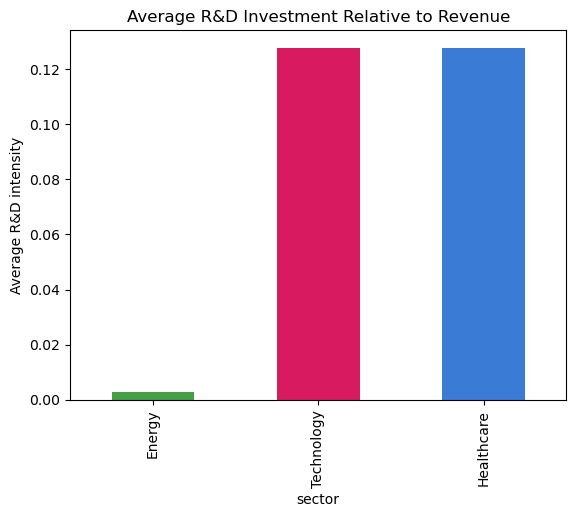

In [11]:
rd_sector = (
    df.groupby("sector")["rd_intensity"]
    .mean()
    .sort_values()
)
colors = {
    "Energy": "#43A047",
    "Healthcare": "#3A7BD5",
    "Technology": "#D81B60"
}
rd_sector.plot(
    kind="bar",
    ylabel="Average R&D intensity",
    title="Average R&D Investment Relative to Revenue",
    color=[colors[sector] for sector in rd_sector.index]
)
plt.show()

### Finding: Technology and Healthcare show the strongest R&D growth strategies

The comparison shows a clear difference in innovation investment between sectors.

Technology and Healthcare companies allocate a significantly larger proportion of revenue to R&D compared with Energy companies. This suggests that these sectors rely more heavily on innovation, research, and new product development to support future growth.

In contrast, Energy companies have much lower R&D intensity, indicating that their growth strategy is less dependent on research spending and more influenced by factors such as physical assets, production capacity, and market conditions.

This supports the idea that different industries follow different growth models: technology and healthcare are more innovation-driven, while energy is more capital and asset-driven.

## 3. Compare profitability across companies

After analysing investment patterns, I examine how effectively companies convert revenue into profits.

Net margin is calculated as:

**Net income ÷ Revenue**

A higher net margin indicates that a company keeps a larger proportion of its revenue as profit after expenses.

This comparison helps identify whether different sectors have different profitability structures and whether companies with stronger internal funding capacity also generate higher returns.

In [12]:
print("Net margin by company and year")

company_order = [
    "ExxonMobil", "Chevron", "Duke Energy",
    "Microsoft", "Nvidia", "Apple",
    "Johnson & Johnson", "Pfizer", "Stryker"
]

net_margin_table = (
    df.pivot_table(
        index="year",
        columns="name",
        values="net_margin"
    )
    .reindex(columns=company_order)
)

net_margin_table.style \
    .format("{:.1%}") \
    .set_table_styles([
        {
            "selector": f"th.col_heading.level0.col{i}",
            "props": [("background-color", company_colors[col])]
        }
        for i, col in enumerate(net_margin_table.columns)
    ])


Net margin by company and year


name,ExxonMobil,Chevron,Duke Energy,Microsoft,Nvidia,Apple,Johnson & Johnson,Pfizer,Stryker
year,,,,,,,,,
2018,7.2%,8.9%,11.2%,31.2%,nan%,22.4%,18.8%,nan%,26.1%
2019,5.4%,2.0%,15.4%,31.0%,25.6%,21.2%,18.4%,nan%,14.0%
2020,-12.4%,-5.9%,5.9%,36.5%,26.0%,20.9%,17.8%,22.0%,11.1%
2021,8.1%,9.6%,16.0%,36.7%,36.2%,25.9%,26.5%,27.0%,11.7%
2022,13.5%,14.4%,8.9%,34.1%,16.2%,25.3%,22.4%,31.0%,12.8%
2023,10.5%,10.6%,9.9%,36.0%,48.8%,25.3%,41.3%,3.6%,15.4%
2024,9.6%,8.7%,15.1%,36.1%,55.8%,24.0%,15.8%,12.6%,13.2%


### Finding: Technology companies demonstrate stronger profitability

The results show that Technology companies generally maintain the highest net margins throughout the period.

Microsoft and Nvidia show particularly strong profitability, reaching net margins above 30% in several years. Apple also maintains consistently high margins compared with most companies in the dataset.

Healthcare companies show mixed profitability. Johnson & Johnson maintains strong margins, while Pfizer's profitability changes significantly over time, particularly around the COVID-19 period.

Energy companies display lower and more variable margins. Chevron and ExxonMobil experience significant changes, including negative margins in 2020, reflecting the impact of energy market conditions.

Overall, the results suggest that technology companies combine innovation-driven growth with highly profitable business models, while energy companies are more exposed to external market cycles.

## 4. Nvidia case study: R&D investment and revenue growth

Nvidia is analysed separately to examine how changes in research and development spending relate to company growth.

The table compares:
- **R&D spending ($bn):** absolute investment in research and development.
- **Revenue ($bn):** annual company revenue.
- **R&D intensity:** R&D expenditure as a percentage of revenue.

This allows comparison between the scale of investment and the proportion of revenue dedicated to innovation over time.

In [13]:
print("Nvidia: R&D spend vs revenue ($bn)")

nvidia_table = (
    df[df["name"] == "Nvidia"][
        ["year", "rd_bn", "revenue_bn", "rd_intensity"]
    ]
    .round(2)
)

nvidia_table.style \
    .format({
        "rd_bn": "{:.2f}",
        "revenue_bn": "{:.2f}",
        "rd_intensity": "{:.1%}"
    }) \
    .set_table_styles([
        {
            "selector": "th.col_heading",
            "props": [("background-color" , company_colors["Nvidia"])]
        }
    ])

Nvidia: R&D spend vs revenue ($bn)


,year,rd_bn,revenue_bn,rd_intensity
56,2018,2.38,nan,nan%
57,2019,2.83,10.92,26.0%
58,2020,3.92,16.68,24.0%
59,2021,5.27,26.91,20.0%
60,2022,7.34,26.97,27.0%
61,2023,8.68,60.92,14.0%
62,2024,12.91,130.50,10.0%


### Interpretation

Nvidia shows a strong increase in absolute R&D investment, rising from **$2.38bn in 2018** to **$12.91bn in 2024**. This reflects a significant expansion in innovation spending as the company scaled its operations.

However, R&D intensity decreased over time, from around **26% in 2019** to **10% in 2024**. This does not indicate lower innovation effort; instead, revenue grew faster than R&D expenditure, particularly during the rapid expansion of Nvidia's AI and data centre businesses.

The results highlight the difference between absolute investment and relative investment. A company can increase its R&D spending substantially while its R&D intensity declines due to faster revenue growth.

## 5. Free cash flow margin across companies

Free cash flow (FCF) margin measures how efficiently companies convert revenue into cash after capital expenditure. It is calculated as:

**FCF margin = (Operating cash flow − Capital expenditure) / Revenue**

The table presents annual free cash flow margins for each company between 2018 and 2024, while the line chart illustrates how these margins evolve over time. Together, they provide both a detailed comparison of annual performance and a visual overview of trends in companies' ability to generate cash internally.

Companies are grouped using consistent colours throughout the analysis:
- Energy companies are shown in green shades.
- Technology companies are shown in pink shades.
- Healthcare companies are shown in blue shades.

The horizontal zero line in the chart highlights years in which companies generated negative free cash flow.

In [14]:
print("Free cash flow margin by company and year")

company_order = [
    "ExxonMobil", "Chevron", "Duke Energy",
    "Microsoft", "Nvidia", "Apple",
    "Johnson & Johnson", "Pfizer", "Stryker"
]

fcf_margin_table = (
    df.pivot_table(
        index="year",
        columns="name",
        values="fcf_margin"
    )
    .reindex(columns=company_order)
    * 100
).round(1)

fcf_margin_table.style \
    .format("{:.1f}%") \
    .set_table_styles([
        {
            "selector": f"th.col_heading.level0.col{i}",
            "props": [("background-color", company_colors[col])]
        }
        for i, col in enumerate(fcf_margin_table.columns)
    ])

Free cash flow margin by company and year


name,ExxonMobil,Chevron,Duke Energy,Microsoft,Nvidia,Apple,Johnson & Johnson,Pfizer,Stryker
year,,,,,,,,,
2018,5.7%,10.1%,-9.3%,30.4%,nan%,24.1%,22.7%,nan%,15.0%
2019,2.0%,9.0%,-12.0%,31.6%,nan%,22.6%,24.3%,nan%,10.4%
2020,-1.4%,1.7%,-4.5%,33.4%,nan%,26.7%,24.4%,29.2%,19.4%
2021,12.6%,13.0%,-5.8%,32.9%,30.2%,25.4%,25.1%,36.7%,16.0%
2022,14.1%,15.3%,-19.0%,28.1%,14.1%,28.3%,21.5%,25.7%,11.0%
2023,9.7%,9.8%,-9.5%,30.2%,44.4%,26.0%,21.4%,8.0%,15.3%
2024,8.8%,7.4%,0.2%,25.4%,46.6%,27.8%,22.3%,15.5%,15.4%


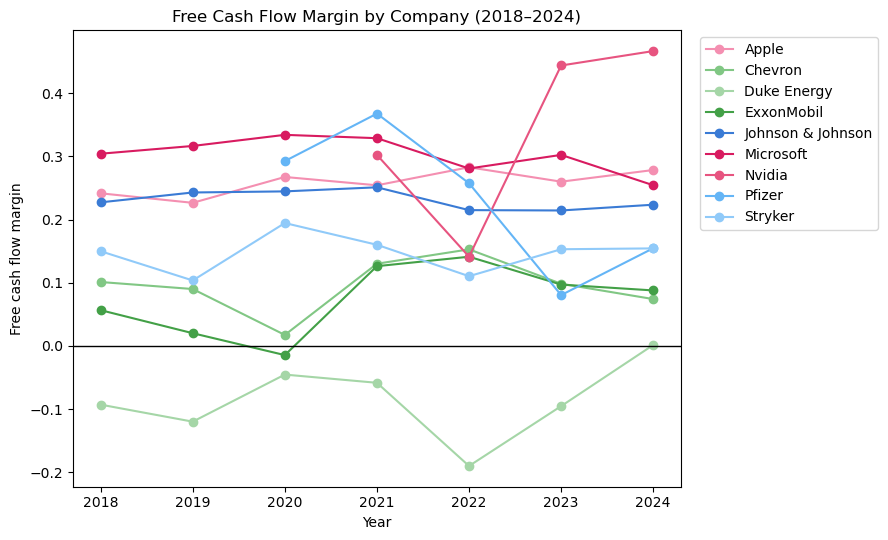

In [15]:
# one column per company, one row per year
fcf = df.pivot(index="year", columns="name", values="fcf_margin")

fcf.plot(
    figsize=(9, 5.5),
    marker="o",
    color=[company_colors[col] for col in fcf.columns]
)

plt.axhline(0, color="black", linewidth=1)

plt.ylabel("Free cash flow margin")
plt.xlabel("Year")
plt.title("Free Cash Flow Margin by Company (2018–2024)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Findings

The results reveal clear differences in cash generation across sectors and companies.

- **Technology companies consistently generate the strongest free cash flow margins.** Microsoft and Apple maintain high and stable margins throughout the period, while Nvidia's free cash flow improves substantially as revenue accelerates after 2022. These results indicate a strong ability to finance growth using internally generated cash.
- **Healthcare companies also demonstrate relatively strong cash generation.** Johnson & Johnson and Stryker maintain consistently positive free cash flow margins, while Pfizer experiences a noticeable decline in 2023 following weaker profitability before partially recovering in 2024.
- **Energy companies show greater volatility and weaker free cash flow generation.** ExxonMobil and Chevron experience lower or negative margins during the 2020 downturn before recovering as market conditions improve. Duke Energy records the weakest free cash flow performance throughout the period, reflecting the large capital investments required in the utility sector.

Overall, the findings suggest that technology companies have the greatest capacity to self-fund growth, whereas capital-intensive sectors such as energy rely more heavily on continuous investment and experience greater fluctuations in cash generation.

## 6. R&D intensity across companies

R&D intensity measures research and development expenditure as a percentage of revenue, allowing companies of different sizes to be compared on a consistent basis.

The table presents annual R&D intensity for each company between 2018 and 2024, while the bar chart summarises the average R&D intensity over the entire period. Together, these outputs show both changes over time and the overall level of investment in innovation.

Companies are grouped using consistent colours throughout the analysis:
- Energy companies are shown in green shades.
- Technology companies are shown in pink shades.
- Healthcare companies are shown in blue shades.

In [16]:
print("R&D intensity by company and year")

company_order = [
    "ExxonMobil", "Chevron", "Duke Energy",
    "Microsoft", "Nvidia", "Apple",
    "Johnson & Johnson", "Pfizer", "Stryker"
]

rd_intensity_table = (
    df.pivot_table(index="year", columns="name", values="rd_intensity")
    .reindex(columns=company_order)
    * 100
).round(1)

rd_intensity_table.style \
    .format("{:.1f}%") \
    .set_table_styles([
        {
            "selector": f"th.col_heading.level0.col{i}",
            "props": [("background-color", company_colors[col])]
        }
        for i, col in enumerate(rd_intensity_table.columns)
    ])


R&D intensity by company and year


name,ExxonMobil,Chevron,Duke Energy,Microsoft,Nvidia,Apple,Johnson & Johnson,Pfizer,Stryker
year,,,,,,,,,
2018,0.4%,0.3%,nan%,13.4%,nan%,5.4%,13.2%,nan%,6.3%
2019,0.5%,0.3%,nan%,13.5%,25.9%,6.2%,13.8%,nan%,6.5%
2020,0.6%,0.5%,nan%,12.3%,23.5%,6.8%,14.7%,20.9%,6.9%
2021,0.3%,0.2%,nan%,12.4%,19.6%,6.0%,18.1%,12.7%,7.2%
2022,0.2%,0.1%,nan%,12.8%,27.2%,6.7%,17.7%,11.3%,7.9%
2023,0.3%,0.2%,nan%,12.0%,14.2%,7.8%,17.7%,17.9%,6.8%
2024,0.3%,0.2%,nan%,11.5%,9.9%,8.0%,19.4%,17.0%,6.5%


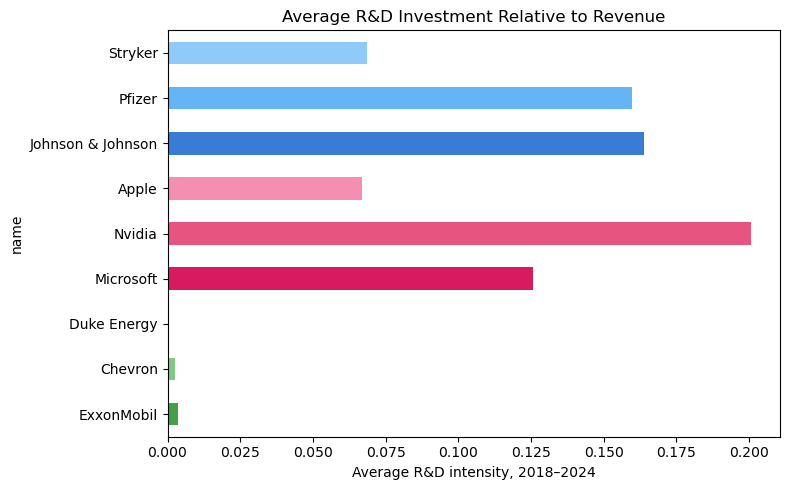

In [17]:
avg = (
    df.groupby("name")["rd_intensity"]
    .mean()
    .reindex([
        "ExxonMobil", "Chevron", "Duke Energy",
        "Microsoft", "Nvidia", "Apple",
        "Johnson & Johnson", "Pfizer", "Stryker"
    ])
)

avg.plot(
    kind="barh",
    figsize=(8, 5),
    color=[company_colors[col] for col in avg.index]
)

plt.xlabel("Average R&D intensity, 2018–2024")
plt.title("Average R&D Investment Relative to Revenue")
plt.tight_layout()
plt.show()

### Findings

The analysis highlights clear differences in research investment across both sectors and individual companies.

- **Technology companies invest the largest share of revenue in R&D.** Microsoft and Nvidia consistently record the highest R&D intensity, reflecting innovation-driven business models. Apple also maintains relatively high R&D investment, although at a lower level than the other two technology firms.

- **Healthcare companies maintain consistently strong research investment.** Johnson & Johnson, Pfizer and Stryker devote a substantial proportion of revenue to R&D, supporting continuous product development and innovation in pharmaceuticals and medical technology.

- **Energy companies invest comparatively little in R&D.** ExxonMobil and Chevron spend less than 1% of revenue on research throughout the period, while Duke Energy reports no R&D expenditure in the available SEC data. This suggests that growth in the energy sector relies more heavily on capital investment and operational assets than on research-intensive innovation.

Overall, the results indicate that sector influences R&D investment patterns, but company strategy also plays an important role, particularly within the technology and healthcare sectors.

## 7. Nvidia case study: Growth in R&D spending

Nvidia is examined separately because it represents a high-growth technology company with a significant increase in research investment over the period.

The chart compares:
- Absolute R&D expenditure ($bn), showing the scale of investment.
- R&D intensity (R&D expenditure as a percentage of revenue), showing the relative commitment to innovation.

Using both measures helps distinguish between growth driven by increasing company size and changes in innovation strategy.

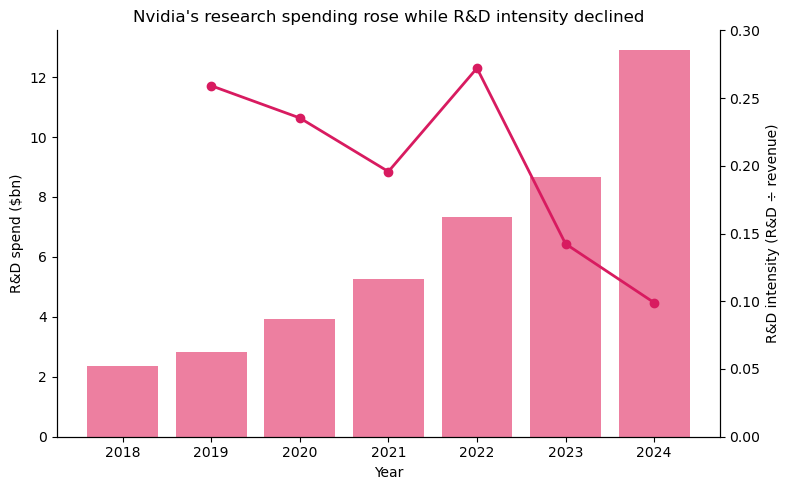

In [18]:
nv = df[df["name"] == "Nvidia"].sort_values("year")

fig, ax1 = plt.subplots(figsize=(8, 5))

# Nvidia company colour
ax1.bar(
    nv["year"],
    nv["rd_bn"],
    color=company_colors["Nvidia"],
    alpha=0.75,
    label="R&D spend ($bn)"
)

ax1.set_ylabel("R&D spend ($bn)")
ax1.set_xlabel("Year")

ax2 = ax1.twinx()

ax2.plot(
    nv["year"],
    nv["rd_intensity"],
    color="#D81B60",
    marker="o",
    linewidth=2,
    label="R&D intensity"
)

ax2.set_ylabel("R&D intensity (R&D ÷ revenue)")
ax2.set_ylim(0, 0.3)

ax1.set_title("Nvidia's research spending rose while R&D intensity declined")

ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)

plt.tight_layout()
plt.show()

### Findings

Nvidia significantly increased its absolute R&D spending between 2018 and 2024, reflecting its expansion in areas such as artificial intelligence and advanced computing.

However, R&D intensity declined over the period. This indicates that revenue growth increased faster than R&D expenditure, meaning Nvidia was able to scale its business while maintaining a lower R&D cost relative to revenue.

This highlights the importance of analysing both absolute investment and revenue-adjusted ratios. A company can increase innovation spending substantially while becoming less R&D-intensive as it grows.

## 8. Average free cash flow generation by company

To summarise the overall ability of companies to generate internal cash, the chart compares the average free cash flow margin for each company between 2018 and 2024.

Using the period average highlights long-term differences in companies' capacity to finance growth through internally generated cash rather than focusing on year-to-year fluctuations.

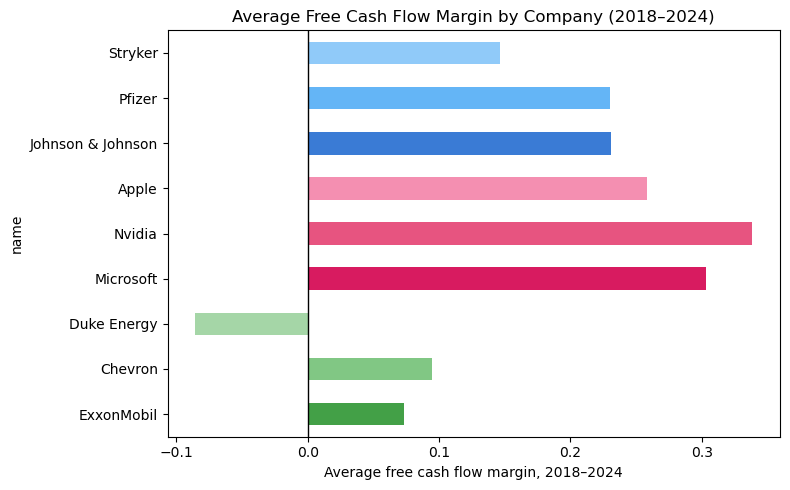

In [19]:
fcf_avg = (
    df.groupby("name")["fcf_margin"]
    .mean()
    .reindex([
        "ExxonMobil", "Chevron", "Duke Energy",
        "Microsoft", "Nvidia", "Apple",
        "Johnson & Johnson", "Pfizer", "Stryker"
    ])
)

fcf_avg.plot(
    kind="barh",
    figsize=(8, 5),
    color=[company_colors[col] for col in fcf_avg.index]
)

plt.axvline(0, color="black", linewidth=1)

plt.xlabel("Average free cash flow margin, 2018–2024")
plt.title("Average Free Cash Flow Margin by Company (2018–2024)")

plt.tight_layout()
plt.show()

### Findings

- **Technology companies achieve the highest average free cash flow margins**, indicating a strong ability to finance growth through internally generated cash.

- **Healthcare companies also maintain positive average free cash flow margins**, although generally below the technology sector.

- **Energy companies rank lowest overall**, with Duke Energy recording the weakest average free cash flow margin due to its capital-intensive business model.

Overall, the average values reinforce the earlier findings that technology companies have the strongest long-term capacity to self-fund growth.